# SafeEarth Intelligence — Machine Learning Report

**A reproducible, end-to-end walkthrough of every ML component that powers [safeearth.tech](https://safeearth.tech).**

This notebook documents the three machine-learning models behind SafeEarth Intelligence,
using the *actual project code, dataset, preprocessing, and saved model artifacts* as the
source of truth — so the numbers here match what runs in production.

| # | Model | Task | How it is evaluated here |
|---|-------|------|--------------------------|
| 1 | **Disaster Type Predictor** | Multiclass classification (8 disaster types) | **Loads the live artifact** `disaster_predictor.pkl` (XGBoost + CatBoost soft ensemble, v4.2) |
| 2 | **Disaster Impact Prediction** | Regression (deaths, injuries, affected, damage) | **Loads the live artifact** `impact_regressor.pkl` (XGBoost + RandomForest, log1p targets) |
| 3 | **Risk Level Classifier** | Multiclass classification (Low / Medium / High / Critical) | **Retrained** (no artifact exists — risk level is *derived* in production), keeping the project's exact features, preprocessing, split, imbalance handling and ensemble |

### Ground rules followed throughout
- **Load, don't retrain, when an artifact exists.** Models 1 & 2 are evaluated from the
  exact `.pkl` files served in production. Model 3 has no artifact (the live site *computes*
  risk level deterministically from predicted impact + probability), so it is retrained while
  keeping the identical 16-feature set, preprocessing, train/test split, imbalance handling
  and XGBoost+CatBoost ensemble the project uses.
- **Reproducibility.** Every random seed is fixed to `42`.
- **Leakage-safe.** The train/test split is the project's own two-file split (train = 1900–2021,
  holdout = the separate 1970–2021 test file). Encoders, region-frequency maps and risk-score
  P99 caps are fit on **train only** and applied to test. No target column is ever used as a
  feature (the impact columns that define the Model-3 risk label are *not* in the feature set).
- **Median, never mean.** SafeEarth's binding rule: impact data is right-skewed 100×+, so all
  impact statistics use the median.

> **Faithfulness note for Model 3.** On the live site the *risk level* is not a standalone
> trained model — it is the band of the 0–100 composite **risk score** computed from the
> predicted impact and probability. This notebook reproduces that exact definition as a
> ground-truth label and trains a direct classifier for it (using only location/time
> features), which is both an honest documentation of the risk-scoring logic and an
> instructive rare-event detection problem.


## A · Environment, reproducibility & faithfulness

We import the libraries, pin every random seed to `42`, and print the exact library
versions so the run is fully reproducible.

In [1]:
import os, re, json, math, warnings, random
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib
import matplotlib.pyplot as plt

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# ── ML stack ─────────────────────────────────────────────────────────────────
import sklearn, xgboost, catboost, shap
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    mean_absolute_error, mean_squared_error, r2_score, explained_variance_score,
    mean_absolute_percentage_error,
)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
try:
    import lightgbm as _lgb; _LGB_VER = _lgb.__version__
except Exception:
    _LGB_VER = "not installed"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.titlesize": 12, "font.size": 10,
})

print("Library versions")
print(f"  numpy        {np.__version__}")
print(f"  pandas       {pd.__version__}")
print(f"  scikit-learn {sklearn.__version__}")
print(f"  xgboost      {xgboost.__version__}")
print(f"  catboost     {catboost.__version__}")
print(f"  lightgbm     {_LGB_VER}   (benchmarked then dropped in the v4.2 ensemble)")
print(f"  shap         {shap.__version__}")
print(f"\nAll random seeds fixed at SEED = {SEED}")

Library versions
  numpy        2.4.1
  pandas       2.3.3
  scikit-learn 1.8.0
  xgboost      3.2.0
  catboost     1.2.10
  lightgbm     4.6.0   (benchmarked then dropped in the v4.2 ensemble)
  shap         0.51.0

All random seeds fixed at SEED = 42


### Paths & project constants

Everything below mirrors `scripts/run_training.py` and
`scripts/generate_emdat_stats.py` exactly:

- **16 features** (`FEATURE_NAMES`) — the production feature vector.
- **8 disaster types** the model is trained on (7 raw EM-DAT types such as *Epidemic* are dropped).
- **Hand-tuned class weights** (`CUSTOM_CLASS_WEIGHTS`) — the production imbalance strategy.
- **Regression targets** — the exact columns the impact regressors were trained on.
- **Risk-score impact columns** — the exact columns the composite risk score uses.

In [2]:
# Walk up to the repo root (the folder containing backend/ and data/)
ROOT = Path.cwd()
while not (ROOT / "backend" / "saved_models").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

TRAIN_CSV  = ROOT / "data" / "train" / "1900_2021_DISASTERS.xlsx - train data.csv"
TEST_CSV   = ROOT / "data" / "test"  / "1970-2021_DISASTERS.xlsx - test data.csv"
MODELS_DIR = ROOT / "backend" / "saved_models"
METRICS_DIR = ROOT / "metrics"

# The 8 supported types (scripts/run_training.py)
VALID_DISASTER_TYPES = [
    "Flood", "Storm", "Earthquake", "Wildfire",
    "Volcanic activity", "Landslide", "Drought", "Extreme temperature",
]

# Production 16-feature vector (scripts/run_training.py FEATURE_NAMES)
FEATURE_NAMES = [
    "latitude", "longitude", "abs_latitude", "lon_sin", "lon_cos",
    "continent_enc", "region_enc", "country_enc", "month_sin", "month_cos",
    "dis_mag_value", "has_magnitude", "historical_freq", "log_hist_freq",
    "decade", "day_offset",
]

# Production hand-tuned class weights (the chosen imbalance strategy)
CUSTOM_CLASS_WEIGHTS = {
    "Flood": 1.0, "Storm": 1.0, "Earthquake": 1.0, "Extreme temperature": 1.5,
    "Wildfire": 2.5, "Volcanic activity": 3.0, "Drought": 4.0, "Landslide": 3.0,
}

# Impact-regressor targets — EXACTLY as scripts/run_training.py trains them
REG_TARGET_COLS = {
    "deaths":   "Total Deaths",
    "injuries": "No Injured",
    "affected": "No Affected",
    "damage":   "Total Damages ('000 US$)",
}

# Composite risk-score impact columns — EXACTLY as build_risk_map() uses them
RISK_COLS = {
    "deaths":   "Total Deaths",
    "affected": "Total Affected",
    "damage":   "Total Damages ('000 US$)",
}

# Severity / risk-level palette (matches frontend SeverityBadge + riskScale.ts)
SEV_COLORS = {"Low": "#16a34a", "Medium": "#facc15", "High": "#f97316", "Critical": "#dc2626"}

for p in [TRAIN_CSV, TEST_CSV, MODELS_DIR / "disaster_predictor.pkl", MODELS_DIR / "impact_regressor.pkl"]:
    assert p.exists(), f"Required file missing: {p}"

print("Repo root :", ROOT)
print("Train CSV :", TRAIN_CSV.name)
print("Test  CSV :", TEST_CSV.name)
print("Features  :", len(FEATURE_NAMES))
print("Types     :", len(VALID_DISASTER_TYPES))
print("All required data + model artifacts found.")

Repo root : D:\safeearth
Train CSV : 1900_2021_DISASTERS.xlsx - train data.csv
Test  CSV : 1970-2021_DISASTERS.xlsx - test data.csv
Features  : 16
Types     : 8
All required data + model artifacts found.


## B · Shared data loading & feature engineering

All three models consume the **same EM-DAT dataset** and the **same preprocessing**,
so we build the feature pipeline once here and reuse it. The function below is a faithful
reproduction of `scripts/run_training.py`.

**Preprocessing & feature engineering (why each step exists):**

1. **Filter to 8 supported types** — drop *Epidemic, Fog, Glacial lake outburst,* etc.
2. **Coordinate cleaning** — EM-DAT stores ~274 coordinates as directional strings
   (`'34.01 N'`, `'78.46 W '`) and some out-of-range DMS artefacts (`36100.0`).
   `parse_coord` repairs these; out-of-range values become NaN.
3. **Coordinate imputation** — only ~19 % of events have raw coordinates, so missing
   lat/lon are filled by **country → continent → global median** (leakage-safe: medians
   are computed within each split).
4. **Cyclical encodings** — `month_sin/cos` and `lon_sin/cos` so the model treats
   December–January and ±180° longitude as adjacent.
5. **`abs_latitude`** — distance from equator, a climate-zone proxy.
6. **`historical_freq` / `log_hist_freq`** — per-region event frequency (a regional prior).
7. **`dis_mag_value` / `has_magnitude`** — magnitude (Richter/Kph/Km²/°C) and a
   present/absent flag. Magnitude is the single most discriminative feature where present.
8. **Label encoders** for continent/region/country are **fit on train only**; unseen
   test categories map to `0`.

**Train arm** imputes a missing start-month from the per-type modal month; the **holdout
arm** uses a constant fill of `6` (June) — both exactly as production does.

In [3]:
def parse_coord(val):
    # EM-DAT lat/lon parser — identical to scripts/run_training.py.
    # Handles '34.01 N' / '78.46 W' directional strings; returns NaN if unparseable.
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return np.nan
    s = str(val).strip().rstrip(".")
    try:
        return float(s)
    except ValueError:
        pass
    m = re.match(r"^([0-9.]+)\s*([NSEWnsew])\s*$", s)
    if m:
        num_str, direction = m.group(1).rstrip("."), m.group(2).upper()
        try:
            num = float(num_str)
            return -num if direction in ("S", "W") else num
        except ValueError:
            pass
    return np.nan


def engineer_features(df, *, fit, region_freq_map=None, encoders=None):
    # Reproduce the production 16-feature pipeline (scripts/run_training.py).
    # fit=True  -> TRAIN arm   : per-type month-mode impute, FIT encoders + region_freq_map.
    # fit=False -> HOLDOUT arm : Start Month fillna(6), TRANSFORM with fitted encoders (unseen->0).
    # Returns (df, X, region_freq_map, encoders).
    df = df.copy()
    df["Disaster Type"] = df["Disaster Type"].str.strip()
    df = df[df["Disaster Type"].isin(VALID_DISASTER_TYPES)].reset_index(drop=True)

    # lat/lon: parse -> range-clip to NaN -> impute country -> continent -> global median
    for col, (lo, hi) in [("Latitude", (-90.0, 90.0)), ("Longitude", (-180.0, 180.0))]:
        df[col] = df[col].apply(parse_coord)
        df.loc[(df[col] < lo) | (df[col] > hi), col] = np.nan
        df[col] = df[col].fillna(df.groupby("Country")[col].transform("median"))
        df[col] = df[col].fillna(df.groupby("Continent")[col].transform("median"))
        df[col] = df[col].fillna(df[col].median())

    df["latitude"]     = df["Latitude"]
    df["longitude"]    = df["Longitude"]
    df["abs_latitude"] = df["latitude"].abs()
    df["lon_sin"]      = np.sin(2 * np.pi * df["longitude"] / 360)
    df["lon_cos"]      = np.cos(2 * np.pi * df["longitude"] / 360)

    if fit:
        month_mode = (df.dropna(subset=["Start Month"])
                        .groupby("Disaster Type")["Start Month"]
                        .agg(lambda x: int(x.mode().iloc[0])).to_dict())
        mr = df["Start Month"].copy()
        for dtype, mv in month_mode.items():
            mr.loc[mr.isna() & (df["Disaster Type"] == dtype)] = mv
        mr = mr.fillna(6).astype(int)
    else:
        mr = df["Start Month"].fillna(6).astype(int)
    df["month_sin"] = np.sin(2 * np.pi * mr / 12)
    df["month_cos"] = np.cos(2 * np.pi * mr / 12)

    df["decade"] = (df["Year"] // 10) * 10
    if fit:
        region_freq_map = df.groupby("Region").size().to_dict()
    df["historical_freq"] = df["Region"].map(region_freq_map).fillna(1).astype(int)
    df["log_hist_freq"]   = np.log1p(df["historical_freq"])
    df["has_magnitude"]   = df["Dis Mag Value"].notna().astype(int)
    df["dis_mag_value"]   = pd.to_numeric(df["Dis Mag Value"], errors="coerce").fillna(0.0)
    df["day_offset"]      = 0

    if fit:
        encoders = {"continent": LabelEncoder(), "region": LabelEncoder(), "country": LabelEncoder()}
        df["continent_enc"] = encoders["continent"].fit_transform(df["Continent"])
        df["region_enc"]    = encoders["region"].fit_transform(df["Region"])
        df["country_enc"]   = encoders["country"].fit_transform(df["Country"])
    else:
        def _safe(le, vals):
            known = set(le.classes_)
            return np.array([le.transform([v])[0] if v in known else 0 for v in vals], dtype=np.int32)
        df["continent_enc"] = _safe(encoders["continent"], df["Continent"])
        df["region_enc"]    = _safe(encoders["region"],    df["Region"])
        df["country_enc"]   = _safe(encoders["country"],   df["Country"])

    X = df[FEATURE_NAMES].values.astype(np.float32)
    assert np.isnan(X).sum() == 0, "NaN leaked into the feature matrix"
    return df, X, region_freq_map, encoders

print("Pipeline functions defined: parse_coord(), engineer_features()")

Pipeline functions defined: parse_coord(), engineer_features()


### Dataset overview — shape, columns, dtypes, missing values

We load the raw EM-DAT train file and print its shape, columns, dtypes and a
missing-value summary for the key fields. The missingness is the headline data-quality
story: only ~19 % of events have coordinates, ~26 % have injuries, ~34 % have magnitude.

In [4]:
raw_train = pd.read_csv(TRAIN_CSV, encoding="latin-1")
raw_test  = pd.read_csv(TEST_CSV,  encoding="latin-1")

print(f"RAW train : {raw_train.shape[0]:,} rows x {raw_train.shape[1]} columns")
print(f"RAW test  : {raw_test.shape[0]:,} rows x {raw_test.shape[1]} columns")
print(f"\nAll {raw_train.shape[1]} columns:")
print(list(raw_train.columns))

modeled = raw_train.copy()
modeled["Disaster Type"] = modeled["Disaster Type"].str.strip()
modeled = modeled[modeled["Disaster Type"].isin(VALID_DISASTER_TYPES)]
n_test_modeled = raw_test["Disaster Type"].str.strip().isin(VALID_DISASTER_TYPES).sum()
print(f"\nAfter filtering to the 8 modeled types:")
print(f"  train: {len(modeled):,} rows   (dropped {len(raw_train) - len(modeled):,} unsupported)")
print(f"  test : {n_test_modeled:,} rows")

print(f"\nDtypes across all columns:")
print(raw_train.dtypes.value_counts().to_string())

key_cols = ["Country", "Region", "Continent", "Latitude", "Longitude", "Dis Mag Value",
            "Start Month", "Year", "Total Deaths", "No Injured", "No Affected",
            "Total Affected", "Total Damages ('000 US$)", "Insured Damages ('000 US$)"]
miss = pd.DataFrame({
    "dtype":     [str(modeled[c].dtype) for c in key_cols],
    "non_null":  [int(modeled[c].notna().sum()) for c in key_cols],
    "present_%": [round(modeled[c].notna().mean() * 100, 1) for c in key_cols],
}, index=key_cols)
print(f"\nMissing-value summary (8-type modeled subset, n={len(modeled):,}):")
print(miss.to_string())

RAW train : 16,126 rows x 45 columns


RAW test  : 14,644 rows x 47 columns

All 45 columns:
['Year', 'Seq', 'Glide', 'Disaster Group', 'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype', 'Disaster Subsubtype', 'Event Name', 'Country', 'ISO', 'Region', 'Continent', 'Location', 'Origin', 'Associated Dis', 'Associated Dis2', 'OFDA Response', 'Appeal', 'Declaration', 'Aid Contribution', 'Dis Mag Value', 'Dis Mag Scale', 'Latitude', 'Longitude', 'Local Time', 'River Basin', 'Start Year', 'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day', 'Total Deaths', 'No Injured', 'No Affected', 'No Homeless', 'Total Affected', "Insured Damages ('000 US$)", "Total Damages ('000 US$)", 'CPI', 'Adm Level', 'Admin1 Code', 'Admin2 Code', 'Geo Locations']

After filtering to the 8 modeled types:
  train: 14,476 rows   (dropped 1,650 unsupported)
  test : 13,070 rows

Dtypes across all columns:
object     27
float64    14
int64       4

Missing-value summary (8-type modeled subset, n=14,476):
                              dtype

### Build the feature matrices and the train/test split

The split is the project's **two-file holdout**: the full 1900–2021 file is training data;
the separate 1970–2021 file is the holdout test set used for every score below.

In [5]:
# TRAIN arm (fits encoders + region_freq_map)
df_train, X_train, region_freq_map, encoders = engineer_features(raw_train, fit=True)
le_target = LabelEncoder()
y_type_train = le_target.fit_transform(df_train["Disaster Type"])
CLASS_NAMES = list(le_target.classes_)

# HOLDOUT arm (transforms with the fitted encoders)
df_test, X_test, _, _ = engineer_features(raw_test, fit=False,
                                          region_freq_map=region_freq_map, encoders=encoders)
y_type_test = le_target.transform(df_test["Disaster Type"])

print(f"X_train : {X_train.shape}   (train events, 16 features)")
print(f"X_test  : {X_test.shape}   (holdout events, 16 features)")
print(f"Split   : train = 1900-2021 file  |  holdout = 1970-2021 file (separate)")
print(f"Classes : {CLASS_NAMES}")
print(f"\nFeature matrix has zero NaNs in both arms: "
      f"{np.isnan(X_train).sum() == 0 and np.isnan(X_test).sum() == 0}")

X_train : (14476, 16)   (train events, 16 features)
X_test  : (13070, 16)   (holdout events, 16 features)
Split   : train = 1900-2021 file  |  holdout = 1970-2021 file (separate)
Classes : ['Drought', 'Earthquake', 'Extreme temperature', 'Flood', 'Landslide', 'Storm', 'Volcanic activity', 'Wildfire']

Feature matrix has zero NaNs in both arms: True


### Reusable evaluation helpers

Confusion-matrix and ROC / Precision-Recall plotters used by both classifiers.

In [6]:
def plot_confusion(y_true, y_pred, class_names, title, labels=None):
    # Confusion matrix: color = row-normalized (so rare classes stay visible),
    # annotation = raw count + row %.
    cm  = confusion_matrix(y_true, y_pred, labels=labels)
    cmn = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    n = len(class_names)
    fig, ax = plt.subplots(figsize=(1.05 * n + 3, 1.0 * n + 2.4))
    im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(n)); ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticks(range(n)); ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    ax.grid(False)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f"{cm[i, j]:,}\n{cmn[i, j]*100:.0f}%", ha="center", va="center",
                    color=("white" if cmn[i, j] > 0.5 else "black"), fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="row-normalized")
    plt.tight_layout(); plt.show()


def plot_roc_pr(y_true, proba, class_names, title_prefix):
    # One-vs-rest ROC and Precision-Recall curves for a multiclass problem.
    # class_names MUST be in the proba-column order (the classifier's classes_).
    K = len(class_names)
    Yb = label_binarize(y_true, classes=range(K))
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    for i, name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(Yb[:, i], proba[:, i])
        ax[0].plot(fpr, tpr, lw=1.6, label=f"{name} (AUC={auc(fpr, tpr):.3f})")
    ax[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
    ax[0].set(xlabel="False positive rate", ylabel="True positive rate",
              title=f"{title_prefix} — ROC (one-vs-rest)")
    ax[0].legend(fontsize=7, loc="lower right")
    for i, name in enumerate(class_names):
        prec, rec, _ = precision_recall_curve(Yb[:, i], proba[:, i])
        ap = average_precision_score(Yb[:, i], proba[:, i])
        ax[1].plot(rec, prec, lw=1.6, label=f"{name} (AP={ap:.3f})")
    ax[1].set(xlabel="Recall", ylabel="Precision",
              title=f"{title_prefix} — Precision-Recall (one-vs-rest)")
    ax[1].legend(fontsize=7, loc="upper right")
    plt.tight_layout(); plt.show()


def plot_importances(importances, feature_names, title, color="#2563eb"):
    order = np.argsort(importances)[::-1]
    plt.figure(figsize=(8, 5.5))
    plt.barh([feature_names[i] for i in order][::-1],
             [importances[i] for i in order][::-1], color=color)
    plt.xlabel("importance"); plt.title(title); plt.grid(axis="x", alpha=0.25)
    plt.tight_layout(); plt.show()


def shap_global_bar(model, X_sample, feature_names, title, color="#7c3aed"):
    # Version-robust SHAP summary: mean(|SHAP|) per feature, averaged over samples
    # (and classes for multiclass). Returns the importance vector.
    expl = shap.TreeExplainer(model)
    sv = np.array(expl.shap_values(X_sample))
    if sv.ndim == 3:                       # locate the feature axis (== n_features)
        feat_axis = list(sv.shape).index(len(feature_names))
        reduce_axes = tuple(a for a in range(3) if a != feat_axis)
        mean_abs = np.abs(sv).mean(axis=reduce_axes)
    else:
        mean_abs = np.abs(sv).mean(axis=0)
    order = np.argsort(mean_abs)[::-1]
    plt.figure(figsize=(8, 5.5))
    plt.barh([feature_names[i] for i in order][::-1], mean_abs[order][::-1], color=color)
    plt.xlabel("mean(|SHAP value|)  —  global feature importance")
    plt.title(title); plt.grid(axis="x", alpha=0.25); plt.tight_layout(); plt.show()
    return mean_abs

print("Evaluation helpers ready: plot_confusion, plot_roc_pr, plot_importances, shap_global_bar")

Evaluation helpers ready: plot_confusion, plot_roc_pr, plot_importances, shap_global_bar


# Model 1 — Disaster Type Predictor

**Task: multiclass classification** — given a location, season, magnitude and regional
context, predict which of the 8 disaster types is most likely.

**Architecture (production v4.2):** a soft-voting ensemble of an **XGBoost** classifier
(weight 0.60) and a **CatBoost** classifier (weight 0.40), each Optuna-tuned. LightGBM was
part of v4.1 but was **dropped in v4.2** (it did not improve macro-F1; see the imbalance
section). We **load the live `disaster_predictor.pkl`** and evaluate it on the holdout set.

### 1.1 Data & target class distribution

(The dataset shape / dtypes / missing-value summary printed in Section B applies to all
three models.) Here we show the **target distribution** for the type classifier — note the
**21× class imbalance** and the weak minority classes **Landslide** and **Drought**.

Disaster-type class distribution:
                     train  test  train_%
Disaster Type                            
Flood                 5551  5272     38.3
Storm                 4496  4005     31.1
Earthquake            1544  1137     10.7
Landslide              776   713      5.4
Drought                770   685      5.3
Extreme temperature    603   584      4.2
Wildfire               471   452      3.3
Volcanic activity      265   222      1.8

Imbalance ratio (largest / smallest, train): 21x
Flood + Storm share of training set: 69%


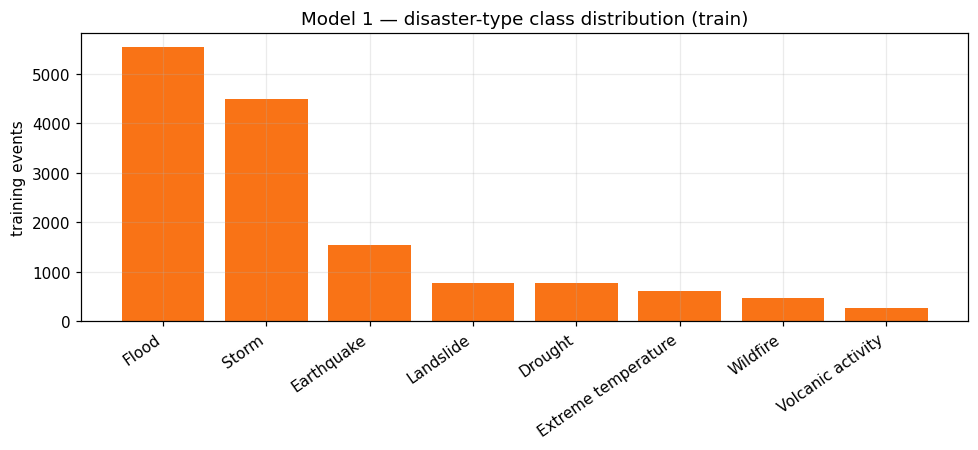

In [7]:
tr_counts = df_train["Disaster Type"].value_counts()
te_counts = df_test["Disaster Type"].value_counts().reindex(tr_counts.index)
dist = pd.DataFrame({"train": tr_counts, "test": te_counts})
dist["train_%"] = (dist["train"] / dist["train"].sum() * 100).round(1)
print("Disaster-type class distribution:")
print(dist.to_string())
print(f"\nImbalance ratio (largest / smallest, train): "
      f"{tr_counts.max() / tr_counts.min():.0f}x")
print(f"Flood + Storm share of training set: "
      f"{(tr_counts['Flood'] + tr_counts['Storm']) / tr_counts.sum() * 100:.0f}%")

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(tr_counts.index, tr_counts.values, color=[SEV_COLORS["High"]]*len(tr_counts))
ax.set_ylabel("training events"); ax.set_title("Model 1 — disaster-type class distribution (train)")
ax.set_xticklabels(tr_counts.index, rotation=35, ha="right"); ax.grid(axis="y", alpha=0.25)
plt.tight_layout(); plt.show()

### 1.2 Imbalance handling — hand-tuned class weights (SMOTE was tested and rejected)

The project handles the imbalance with **per-class sample weights**, not resampling. The
weights up-weight the rare/hard classes (Drought 4.0, Volcanic 3.0, Landslide 3.0, Wildfire
2.5) and leave the abundant classes at 1.0.

Crucially, **SMOTE and inverse-frequency balancing were both rigorously tested with 5-fold
CV and *rejected*** — every resampling strategy regressed the holdout macro-F1, because the
bottleneck is *missing magnitude signal*, not missing rows. The numbers below are read live
from `metrics/minority_strategies_v4_2.json`.

In [8]:
# Class-weight strategy: raw counts -> effective (weighted) counts
w = pd.Series(CUSTOM_CLASS_WEIGHTS)
ct = df_train["Disaster Type"].value_counts()
weight_tbl = pd.DataFrame({
    "raw_count":        ct,
    "class_weight":     w.reindex(ct.index),
    "effective_weight": (ct * w.reindex(ct.index)).round(0).astype(int),
}).sort_values("class_weight", ascending=False)
print("Imbalance strategy = hand-tuned class weights (production):")
print(weight_tbl.to_string())

# SMOTE / balanced-weights experiment outcomes (read from the metrics paper trail)
strat = json.loads((METRICS_DIR / "minority_strategies_v4_2.json").read_text())["strategies"]
exp = pd.DataFrame([
    {"strategy": "Hand-tuned weights (CHOSEN)",   "holdout_macro_f1": strat["hand_weights"]["holdout_macro"],        "decision": strat["hand_weights"]["decision"]},
    {"strategy": "Balanced inverse-freq weights", "holdout_macro_f1": strat["balanced_inv_freq"]["holdout_macro"],   "decision": strat["balanced_inv_freq"]["decision"]},
    {"strategy": "SMOTE oversampling",            "holdout_macro_f1": strat["smote_minority_per_fold"]["holdout_macro"], "decision": strat["smote_minority_per_fold"]["decision"]},
])
print("\nResampling experiment (5-fold CV decision rule: keep iff holdout gain > CV std):")
print(exp.to_string(index=False))

Imbalance strategy = hand-tuned class weights (production):
                     raw_count  class_weight  effective_weight
Disaster Type                                                 
Drought                    770           4.0              3080
Landslide                  776           3.0              2328
Volcanic activity          265           3.0               795
Wildfire                   471           2.5              1178
Extreme temperature        603           1.5               904
Earthquake                1544           1.0              1544
Flood                     5551           1.0              5551
Storm                     4496           1.0              4496

Resampling experiment (5-fold CV decision rule: keep iff holdout gain > CV std):
                     strategy  holdout_macro_f1 decision
  Hand-tuned weights (CHOSEN)            0.7052     KEEP
Balanced inverse-freq weights            0.6157  DISCARD
           SMOTE oversampling            0.6605  DISCARD


### 1.3 Load the production model & show its hyperparameters

We load the exact `disaster_predictor.pkl` served in production and **assert** that the
notebook's freshly-fit encoders and target classes are byte-for-byte identical to the
artifact's — proving the evaluation below uses the same feature space the model was trained
on.

In [9]:
bundle = joblib.load(MODELS_DIR / "disaster_predictor.pkl")

# Faithfulness assertions: our independently-fit encoders must match the saved artifact.
assert CLASS_NAMES == list(bundle["le_target"].classes_)
assert list(encoders["continent"].classes_) == list(bundle["le_continent"].classes_)
assert list(encoders["region"].classes_)    == list(bundle["le_region"].classes_)
assert list(encoders["country"].classes_)   == list(bundle["le_country"].classes_)
print("Encoders + target classes match the saved artifact EXACTLY.  (faithful evaluation)\n")

clf_xgb = bundle["model"]
clf_cat = bundle["cat_model"]
W_XGB, W_CAT, W_LGB = bundle["xgb_weight"], bundle["cat_weight"], bundle["lgb_weight"]
print(f"Model version : {bundle.get('version', 'v4.2')}")
print(f"Ensemble      : XGBoost x {W_XGB}  +  CatBoost x {W_CAT}   (LightGBM x {W_LGB} -> dropped)")

xp = clf_xgb.get_params()
print("\nXGBoost (Optuna-tuned) hyperparameters:")
for k in ["n_estimators", "max_depth", "learning_rate", "subsample", "colsample_bytree",
          "min_child_weight", "gamma", "reg_alpha", "reg_lambda"]:
    print(f"  {k:<18}= {xp[k]}")
cp = clf_cat.get_params()
print("\nCatBoost (Optuna-tuned) hyperparameters:")
for k in ["iterations", "depth", "learning_rate", "l2_leaf_reg", "border_count"]:
    print(f"  {k:<18}= {cp.get(k)}")

Encoders + target classes match the saved artifact EXACTLY.  (faithful evaluation)

Model version : v4.2
Ensemble      : XGBoost x 0.6  +  CatBoost x 0.4   (LightGBM x 0.0 -> dropped)

XGBoost (Optuna-tuned) hyperparameters:
  n_estimators      = 481
  max_depth         = 8
  learning_rate     = 0.05187463761442706
  subsample         = 0.8302660565211304
  colsample_bytree  = 0.5614578448080267
  min_child_weight  = 4
  gamma             = 0.5007073736271453
  reg_alpha         = 1.849828250878654
  reg_lambda        = 2.3962531922058874

CatBoost (Optuna-tuned) hyperparameters:
  iterations        = 426
  depth             = 6
  learning_rate     = 0.16872443214156704
  l2_leaf_reg       = 9.70782790938596
  border_count      = 123


### 1.4 All classification scores on the holdout set

Accuracy, balanced accuracy, macro **and** weighted precision/recall/F1, the full
per-class `classification_report`, and macro ROC-AUC / PR-AUC (one-vs-rest).

In [10]:
# Soft-ensemble probabilities (exactly the production inference path in predictor.py)
proba1 = W_XGB * clf_xgb.predict_proba(X_test) + W_CAT * clf_cat.predict_proba(X_test)
pred1  = np.argmax(proba1, axis=1)

Yb1 = label_binarize(y_type_test, classes=range(len(CLASS_NAMES)))
pr_auc_macro_1 = float(np.mean([average_precision_score(Yb1[:, i], proba1[:, i])
                                for i in range(len(CLASS_NAMES))]))

results_m1 = {
    "accuracy":          accuracy_score(y_type_test, pred1),
    "balanced_accuracy": balanced_accuracy_score(y_type_test, pred1),
    "precision_macro":   precision_score(y_type_test, pred1, average="macro", zero_division=0),
    "recall_macro":      recall_score(y_type_test, pred1, average="macro", zero_division=0),
    "f1_macro":          f1_score(y_type_test, pred1, average="macro", zero_division=0),
    "precision_weighted":precision_score(y_type_test, pred1, average="weighted", zero_division=0),
    "recall_weighted":   recall_score(y_type_test, pred1, average="weighted", zero_division=0),
    "f1_weighted":       f1_score(y_type_test, pred1, average="weighted", zero_division=0),
    "roc_auc_macro":     roc_auc_score(y_type_test, proba1, multi_class="ovr", average="macro"),
    "pr_auc_macro":      pr_auc_macro_1,
}
print(f"Holdout set: {len(y_type_test):,} events\n")
print(f"Accuracy             : {results_m1['accuracy']:.4f}")
print(f"Balanced accuracy    : {results_m1['balanced_accuracy']:.4f}")
print(f"Precision  (macro)   : {results_m1['precision_macro']:.4f}")
print(f"Recall     (macro)   : {results_m1['recall_macro']:.4f}")
print(f"F1         (macro)   : {results_m1['f1_macro']:.4f}   <-- primary metric")
print(f"Precision  (weighted): {results_m1['precision_weighted']:.4f}")
print(f"Recall     (weighted): {results_m1['recall_weighted']:.4f}")
print(f"F1         (weighted): {results_m1['f1_weighted']:.4f}")
print(f"ROC-AUC OvR (macro)  : {results_m1['roc_auc_macro']:.4f}")
print(f"PR-AUC  OvR (macro)  : {results_m1['pr_auc_macro']:.4f}")
print("\nPer-class classification report:")
print(classification_report(y_type_test, pred1, target_names=CLASS_NAMES, digits=4, zero_division=0))

Holdout set: 13,070 events

Accuracy             : 0.7537
Balanced accuracy    : 0.7251
Precision  (macro)   : 0.6975
Recall     (macro)   : 0.7251
F1         (macro)   : 0.7052   <-- primary metric
Precision  (weighted): 0.7699
Recall     (weighted): 0.7537
F1         (weighted): 0.7587
ROC-AUC OvR (macro)  : 0.9624
PR-AUC  OvR (macro)  : 0.7705

Per-class classification report:
                     precision    recall  f1-score   support

            Drought     0.4815    0.7591    0.5892       685
         Earthquake     0.9763    0.9763    0.9763      1137
Extreme temperature     0.8162    0.6918    0.7488       584
              Flood     0.8156    0.7434    0.7778      5272
          Landslide     0.4270    0.5540    0.4823       713
              Storm     0.7753    0.7675    0.7714      4005
  Volcanic activity     0.6331    0.7072    0.6681       222
           Wildfire     0.6554    0.6018    0.6275       452

           accuracy                         0.7537     13070
     

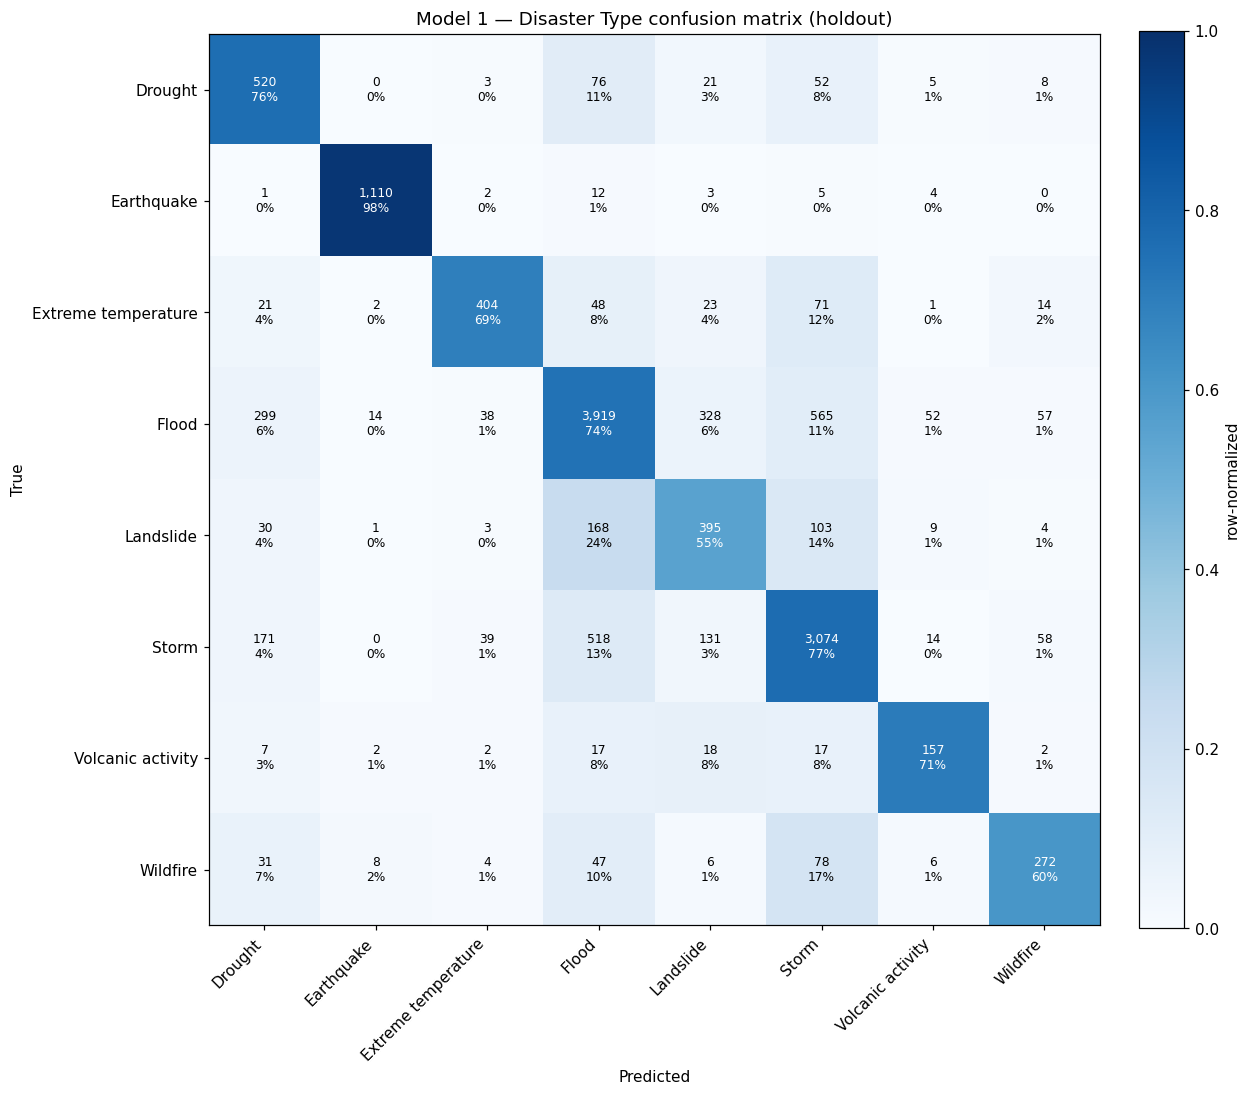

In [11]:
plot_confusion(y_type_test, pred1, CLASS_NAMES,
               "Model 1 — Disaster Type confusion matrix (holdout)",
               labels=list(range(len(CLASS_NAMES))))

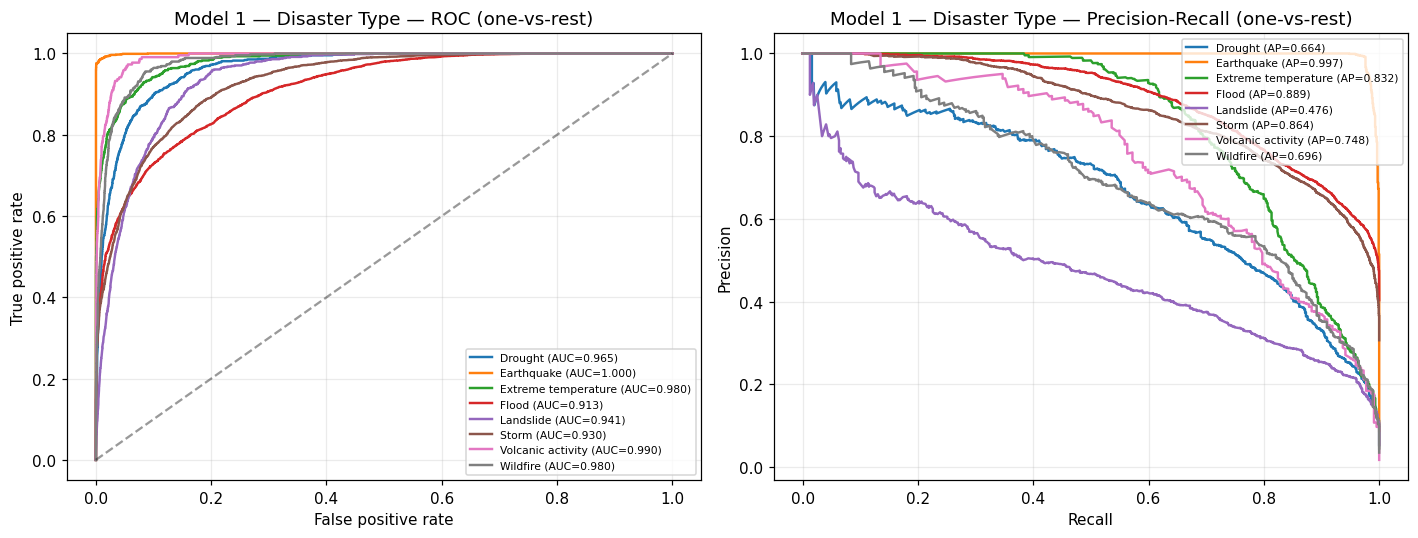

In [12]:
plot_roc_pr(y_type_test, proba1, CLASS_NAMES, "Model 1 — Disaster Type")

### 1.5 The macro-F1 vs weighted-F1 trade-off (why this mattered to the project)

This is the single most important evaluation decision in SafeEarth. With a 21× imbalance,
**accuracy and weighted-F1 are dominated by the two huge classes (Flood, Storm)**; a model
that simply predicted "Flood" everywhere would already look ~38 % accurate.

- **Weighted-F1** averages per-class F1 weighted by support → it rewards being right on the
  common classes and barely notices the rare ones.
- **Macro-F1** averages per-class F1 with **equal weight** → one model is only as good as its
  *worst* class. Landslide (0.48) and Drought (0.59) drag macro-F1 down to ~0.71 even though
  weighted-F1 is ~0.76.

SafeEarth optimises **macro-F1** precisely so the rare disasters are not ignored — and that
choice is exactly why hand-tuned class weights beat SMOTE/balanced weights (which raised rare
recall but cratered Flood/Storm, hurting macro-F1 overall).

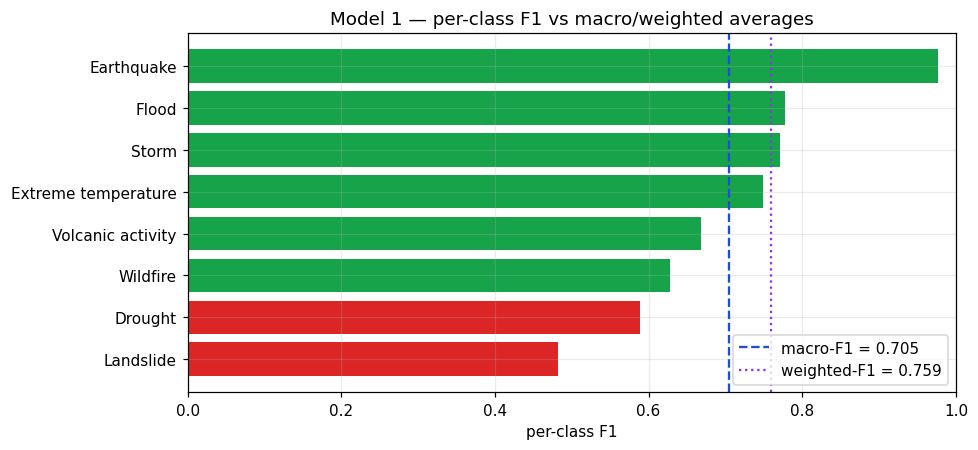

In [13]:
per_class_f1 = f1_score(y_type_test, pred1, average=None, zero_division=0)
order = np.argsort(per_class_f1)
fig, ax = plt.subplots(figsize=(9, 4.2))
bars = ax.barh([CLASS_NAMES[i] for i in order], [per_class_f1[i] for i in order],
               color=[SEV_COLORS["Critical"] if per_class_f1[i] < 0.6 else SEV_COLORS["Low"] for i in order])
ax.axvline(results_m1["f1_macro"],    color="#1d4ed8", ls="--", label=f"macro-F1 = {results_m1['f1_macro']:.3f}")
ax.axvline(results_m1["f1_weighted"], color="#9333ea", ls=":",  label=f"weighted-F1 = {results_m1['f1_weighted']:.3f}")
ax.set_xlabel("per-class F1"); ax.set_xlim(0, 1)
ax.set_title("Model 1 — per-class F1 vs macro/weighted averages"); ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.25); plt.tight_layout(); plt.show()

### 1.6 Explainability — feature importances & SHAP

Production explains predictions with a SHAP `TreeExplainer` on the XGBoost member, rebuilt
from the in-memory model (no separate pkl). We show XGBoost's gain importances and a SHAP
global-importance summary.

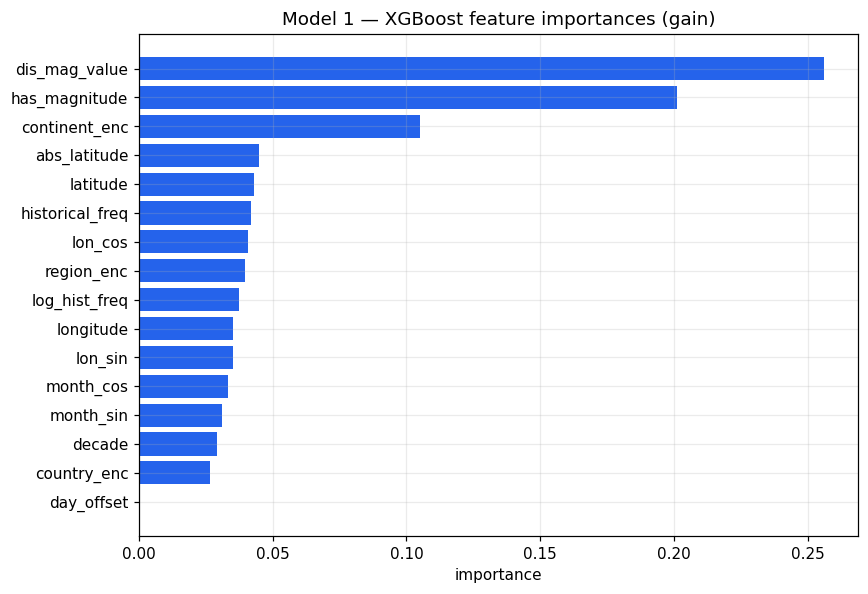

In [14]:
plot_importances(clf_xgb.feature_importances_, FEATURE_NAMES,
                 "Model 1 — XGBoost feature importances (gain)")

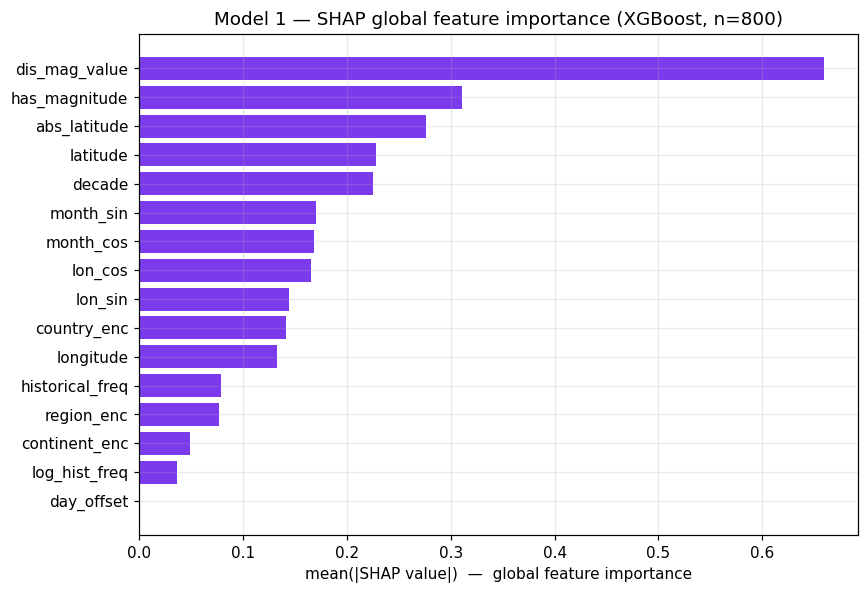

In [15]:
# SHAP on a fixed 800-row sample for speed (multiclass -> mean |SHAP| over samples & classes)
rng = np.random.default_rng(SEED)
idx = rng.choice(len(X_test), size=min(800, len(X_test)), replace=False)
_ = shap_global_bar(clf_xgb, X_test[idx], FEATURE_NAMES,
                    "Model 1 — SHAP global feature importance (XGBoost, n=800)")

**Interpretation.** Magnitude (`dis_mag_value`, `has_magnitude`) and geography
(`latitude`, `continent_enc`, `region_enc`) dominate. This is the root cause of the per-class
spread: **Earthquake** has a magnitude reading in ~94 % of rows (distinct Richter scale) and
scores **0.98 F1**, while **Landslide / Volcanic** have magnitude in ~1 % of rows and sit at
the bottom. The model is only as strong as its rarest feature — better magnitude coverage for
the weak classes is the highest-leverage data fix.

# Model 2 — Disaster Impact Prediction

**Task: regression** — estimate the human and economic toll of an event:
`Total Deaths`, `No Injured`, `No Affected`, and `Total Damages ('000 US$)`.

**Architecture (production):** four regressors bundled in `impact_regressor.pkl`:

| Target | Model |
|--------|-------|
| deaths   | **XGBoost** regressor |
| damage   | **XGBoost** regressor |
| injuries | **RandomForest** regressor |
| affected | **RandomForest** regressor |

All four are trained on **`log1p(target)`** (impact is right-skewed 100×+), so predictions are
`expm1`-inverted and clipped at 0. We **load the live artifact** and evaluate on the holdout.

### 2.1 Targets & their distributions (why median, never mean)

Impact is dominated by a handful of catastrophes. We print mean vs median for each target to
expose the skew — and note the **coverage** of each field (deaths/affected ~70 %+,
damage ~34 %, injuries ~26 %), which bounds how well any model can do and is why the live UI
shows *"based on ~X % of recorded events"* under Injured and Damage.

Impact target distributions (train) — mean is wildly inflated by outliers:
  target                   column  coverage_%     mean  median  median(>0)       max
  deaths             Total Deaths        69.7   1576.4     6.0        17.0   3700000
injuries               No Injured        25.8    531.2     0.0        50.0   1800000
affected              No Affected        55.6 558521.0   400.0     15000.0 330000000
  damage Total Damages ('000 US$)        36.2 262559.2     0.0     60000.0 210000000


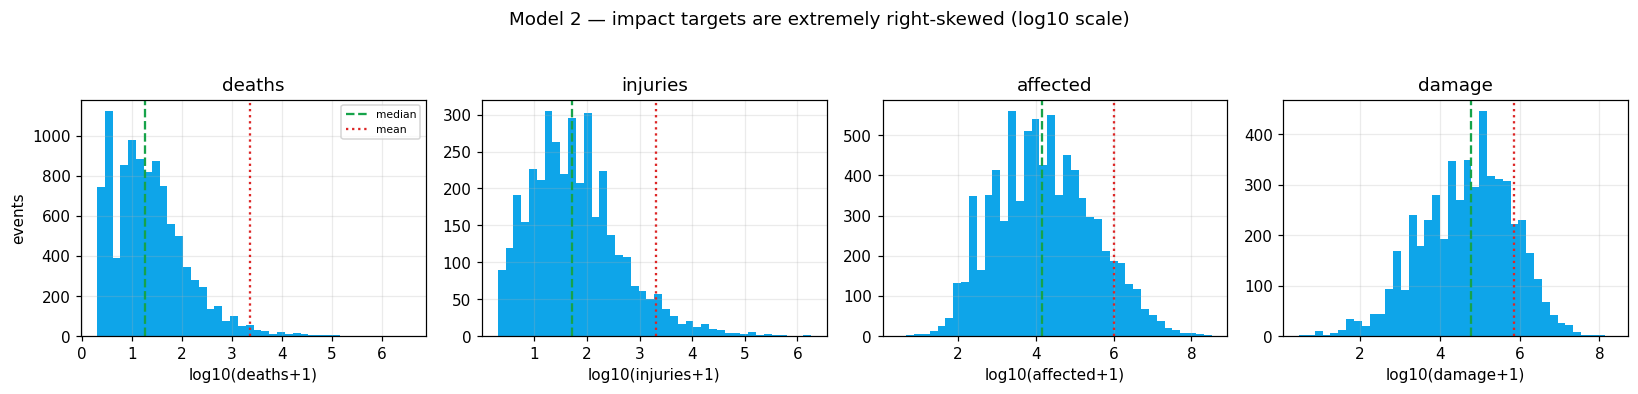

In [16]:
def reg_target(df, col):
    return pd.to_numeric(df[col], errors="coerce").fillna(0).clip(lower=0).values

rows = []
for key, col in REG_TARGET_COLS.items():
    vals = reg_target(df_train, col)
    nz = vals[vals > 0]
    rows.append({
        "target": key, "column": col,
        "coverage_%": round(df_train[col].notna().mean() * 100, 1),
        "mean": round(float(vals.mean()), 1),
        "median": round(float(np.median(vals)), 1),
        "median(>0)": round(float(np.median(nz)) if len(nz) else 0.0, 1),
        "max": int(vals.max()),
    })
print("Impact target distributions (train) — mean is wildly inflated by outliers:")
print(pd.DataFrame(rows).to_string(index=False))

fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))
for ax, (key, col) in zip(axes, REG_TARGET_COLS.items()):
    v = reg_target(df_train, col); v = v[v > 0]
    ax.hist(np.log10(v + 1), bins=40, color="#0ea5e9")
    ax.axvline(np.log10(np.median(v) + 1), color="#16a34a", ls="--", label="median")
    ax.axvline(np.log10(v.mean() + 1),     color="#dc2626", ls=":",  label="mean")
    ax.set_title(key); ax.set_xlabel(f"log10({key}+1)")
    if ax is axes[0]:
        ax.set_ylabel("events"); ax.legend(fontsize=7)
plt.suptitle("Model 2 — impact targets are extremely right-skewed (log10 scale)", y=1.04)
plt.tight_layout(); plt.show()

### 2.2 Load the production regressors & their hyperparameters

In [17]:
regs = joblib.load(MODELS_DIR / "impact_regressor.pkl")
print("impact_regressor.pkl members:")
for k, v in regs.items():
    print(f"  {k:<9}-> {type(v).__name__}")

print("\nXGBoost regressor hyperparameters (deaths & damage):")
xr = regs["deaths"].get_params()
for k in ["n_estimators", "max_depth", "learning_rate", "subsample", "colsample_bytree"]:
    print(f"  {k:<16}= {xr[k]}")
print("\nRandomForest regressor hyperparameters (injuries & affected):")
rr = regs["injuries"].get_params()
for k in ["n_estimators", "max_depth", "min_samples_leaf"]:
    print(f"  {k:<16}= {rr[k]}")
print("\nTargets trained on log1p()  ->  predictions are expm1-inverted and clipped at 0.")

impact_regressor.pkl members:
  deaths   -> XGBRegressor
  injuries -> RandomForestRegressor
  affected -> RandomForestRegressor
  damage   -> XGBRegressor

XGBoost regressor hyperparameters (deaths & damage):
  n_estimators    = 300
  max_depth       = 5
  learning_rate   = 0.08
  subsample       = 0.8
  colsample_bytree= 0.8

RandomForest regressor hyperparameters (injuries & affected):
  n_estimators    = 200
  max_depth       = 10
  min_samples_leaf= 5

Targets trained on log1p()  ->  predictions are expm1-inverted and clipped at 0.


### 2.3 All regression scores on the holdout set

We report **MAE, RMSE, R², MAPE and explained-variance** in two spaces:

- **log1p space** — where the models are actually trained and well-behaved (this is the
  honest headline accuracy).
- **original units** — interpretable, but R² there is brittle because a single catastrophic
  outlier dominates the sum of squares (we report it transparently anyway).

MAPE is computed on the non-zero-actual subset (percentage error is undefined at 0).

In [18]:
def rmse(a, b):
    return float(np.sqrt(mean_squared_error(a, b)))

rows = []
preds_orig = {}
for key, col in REG_TARGET_COLS.items():
    yraw  = reg_target(df_test, col)
    ylog  = np.log1p(yraw)
    plog  = regs[key].predict(X_test)
    porig = np.expm1(plog).clip(min=0)
    preds_orig[key] = (yraw, porig)
    nz = yraw > 0
    rows.append({
        "target": key,
        "R2_log":   round(r2_score(ylog, plog), 4),
        "MAE_log":  round(mean_absolute_error(ylog, plog), 4),
        "RMSE_log": round(rmse(ylog, plog), 4),
        "ExplVar_log": round(explained_variance_score(ylog, plog), 4),
        "R2_orig":  round(r2_score(yraw, porig), 4),
        "MAE_orig": round(mean_absolute_error(yraw, porig), 1),
        "RMSE_orig":round(rmse(yraw, porig), 1),
        "MAPE_orig(nz)": round(float(mean_absolute_percentage_error(yraw[nz], porig[nz])), 3) if nz.sum() else np.nan,
    })
reg_scores = pd.DataFrame(rows).set_index("target")
results_m2 = {"mean_R2_log": float(reg_scores["R2_log"].mean()), "per_target": reg_scores}
print("Model 2 — regression scores on holdout:\n")
print(reg_scores.to_string())
print(f"\nMean R2 (log space) across the 4 targets: {results_m2['mean_R2_log']:.4f}")
print("Note: original-scale R2 is dominated by extreme outliers (right-skew) — log-space R2"
      "\nis the fair headline; production further blends these with EM-DAT type-medians.")

Model 2 — regression scores on holdout:

          R2_log  MAE_log  RMSE_log  ExplVar_log  R2_orig  MAE_orig  RMSE_orig  MAPE_orig(nz)
target                                                                                       
deaths    0.4127   1.1294    1.4442       0.4128   0.0041     255.3     5724.9          1.036
injuries  0.3876   1.1079    1.6062       0.3876  -0.0003     498.5    17074.9          1.169
affected  0.3105   3.7110    4.3780       0.3111  -0.0035  594376.0  7165309.0          2.371
damage    0.3982   3.4623    4.2684       0.3982   0.0034  280721.0  3007570.9          1.603

Mean R2 (log space) across the 4 targets: 0.3772
Note: original-scale R2 is dominated by extreme outliers (right-skew) — log-space R2
is the fair headline; production further blends these with EM-DAT type-medians.


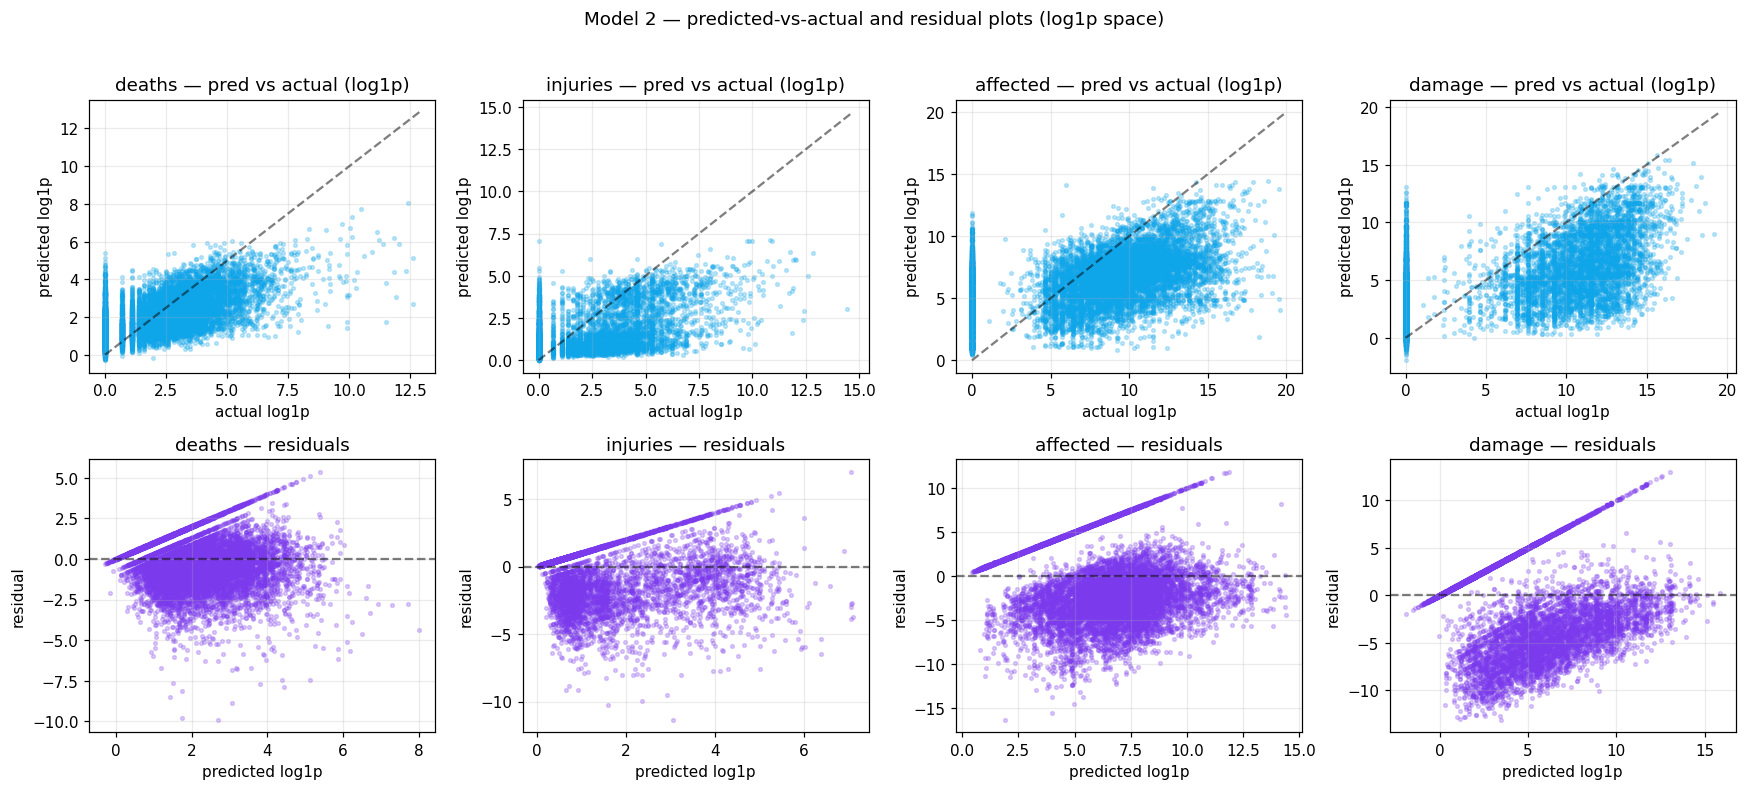

In [19]:
# Predicted vs actual (log space) + residuals
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for j, (key, col) in enumerate(REG_TARGET_COLS.items()):
    yraw = reg_target(df_test, col); ylog = np.log1p(yraw)
    plog = regs[key].predict(X_test)
    # predicted vs actual
    ax = axes[0, j]
    ax.scatter(ylog, plog, s=6, alpha=0.25, color="#0ea5e9")
    lim = [0, max(ylog.max(), plog.max()) * 1.02]
    ax.plot(lim, lim, "k--", alpha=0.5)
    ax.set_title(f"{key} — pred vs actual (log1p)")
    ax.set_xlabel("actual log1p"); ax.set_ylabel("predicted log1p")
    # residuals
    ax = axes[1, j]
    resid = plog - ylog
    ax.scatter(plog, resid, s=6, alpha=0.25, color="#7c3aed")
    ax.axhline(0, color="k", ls="--", alpha=0.5)
    ax.set_title(f"{key} — residuals")
    ax.set_xlabel("predicted log1p"); ax.set_ylabel("residual")
plt.suptitle("Model 2 — predicted-vs-actual and residual plots (log1p space)", y=1.02)
plt.tight_layout(); plt.show()

### 2.4 Explainability — feature importances & SHAP (deaths regressor)

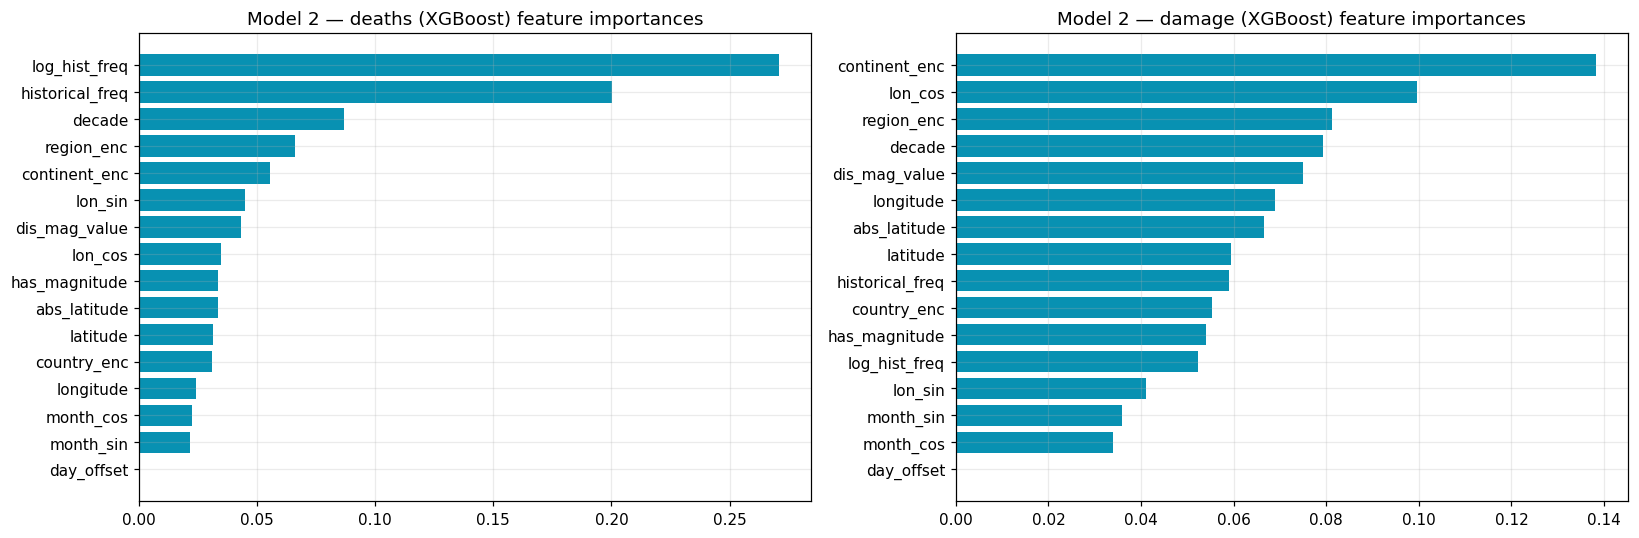

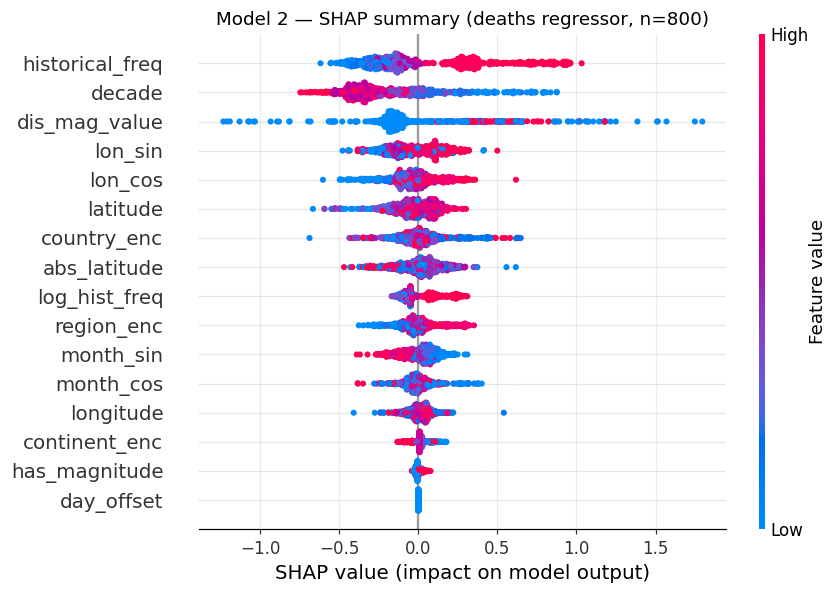

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, key in zip(axes, ["deaths", "damage"]):
    imp = regs[key].feature_importances_
    order = np.argsort(imp)[::-1]
    ax.barh([FEATURE_NAMES[i] for i in order][::-1], imp[order][::-1], color="#0891b2")
    ax.set_title(f"Model 2 — {key} (XGBoost) feature importances"); ax.grid(axis="x", alpha=0.25)
plt.tight_layout(); plt.show()

# SHAP beeswarm for the deaths regressor (single-output -> clean summary plot)
idx = rng.choice(len(X_test), size=min(800, len(X_test)), replace=False)
try:
    expl = shap.TreeExplainer(regs["deaths"])
    sv = expl.shap_values(X_test[idx])
    shap.summary_plot(sv, X_test[idx], feature_names=FEATURE_NAMES, show=False, plot_size=(8, 5.5))
    plt.title("Model 2 — SHAP summary (deaths regressor, n=800)")
    plt.tight_layout(); plt.show()
except Exception as e:
    print("SHAP beeswarm fell back to bar:", e)
    shap_global_bar(regs["deaths"], X_test[idx], FEATURE_NAMES,
                    "Model 2 — SHAP global importance (deaths regressor)")

**Interpretation.** The impact regressors use only the 16 geographic/temporal features
— they are **location-aware but disaster-type-blind**, so log-space R² is modest and weakest
for `injuries` (only ~26 % coverage). This is *by design*: in production these raw predictions
are **blended with EM-DAT type-specific median impacts** (deaths/affected 70 % EM-DAT,
injuries 70 % ML, damage 65 % ML) and constrained to `deaths ≤ injured ≤ affected`, so the
final shown numbers differ by disaster type and stay historically grounded. The model here is
the *location signal*; the EM-DAT lookup supplies the *type signal*.

# Model 3 — Risk Level Classifier

**Task: multiclass classification** — predict the **risk level** (Low / Medium / High /
Critical) of an event from location & time.

**What "risk level" means in SafeEarth.** The live site assigns every prediction a 0–100
**composite risk score** and bands it into four levels via the frontend `getRiskLevel()`
(`riskScale.ts`): **Low 0–30 · Medium 31–55 · High 56–75 · Critical 76–100**. The risk score
is the project's documented formula (`generate_emdat_stats.build_risk_map`):

$$\text{risk} = \big(0.35\,\widehat{deaths} + 0.30\,\widehat{affected} + 0.20\,\widehat{damage} + 0.15\cdot p\big)\times100$$

where each impact term is normalised against the disaster type's P99 cap and, for a
*historical* event, the probability term `p = 1.0`.

**Why this section retrains.** There is **no saved artifact** for risk level — on the live
site it is *computed deterministically* from the predicted impact and probability, not
predicted by a model. To document it as a model (and to test how learnable it is), we:

1. Build the **ground-truth risk label** for every event with the exact formula + bands above.
2. Train a classifier with the **identical 16 features, preprocessing, train/test split,
   class-weight imbalance handling, and XGBoost+CatBoost (60/40) ensemble** the project uses.

**Leakage-safety.** The P99 caps are fit on **train only**. The risk label is derived from the
impact columns, and **those impact columns are NOT in the 16-feature input** — so the label
cannot leak through the features. The classifier must infer risk purely from location/season.

### 3.1 Derive the risk-level labels (exact production formula)

In [21]:
# Numeric impact columns (train + test)
for c in set(RISK_COLS.values()):
    df_train[c] = pd.to_numeric(df_train[c], errors="coerce")
    df_test[c]  = pd.to_numeric(df_test[c],  errors="coerce")

# P99 caps per disaster type — FIT ON TRAIN ONLY (leakage-safe), reused for test
P99_CAPS = {t: {c: float(g[c].quantile(0.99)) for c in RISK_COLS.values()}
            for t, g in df_train.groupby("Disaster Type")}

def risk_score_row(row):
    cap = P99_CAPS[row["Disaster Type"]]
    def nz(v): return 0.0 if pd.isna(v) else float(v)
    d = min(nz(row[RISK_COLS["deaths"]])   / (cap[RISK_COLS["deaths"]]   or 1.0), 1.0)
    a = min(nz(row[RISK_COLS["affected"]]) / (cap[RISK_COLS["affected"]] or 1.0), 1.0)
    m = min(nz(row[RISK_COLS["damage"]])   / (cap[RISK_COLS["damage"]]   or 1.0), 1.0)
    return (d * 0.35 + a * 0.30 + m * 0.20 + 1.0 * 0.15) * 100.0   # historical event -> p=1.0

def risk_level(s):                       # frontend getRiskLevel() bands
    if s >= 76: return "Critical"
    if s >= 56: return "High"
    if s >= 31: return "Medium"
    return "Low"

for d in (df_train, df_test):
    d["risk_score"] = d.apply(risk_score_row, axis=1)
    d["risk_level"] = d["risk_score"].apply(risk_level)

RISK_ORDER = ["Low", "Medium", "High", "Critical"]   # display order (low -> high)
print("Risk-score distribution (train):")
print(df_train["risk_score"].describe()[["min", "25%", "50%", "75%", "max"]].round(2).to_string())
print("\nRisk-level distribution:")
rl = pd.DataFrame({
    "train": df_train["risk_level"].value_counts().reindex(RISK_ORDER),
    "test":  df_test["risk_level"].value_counts().reindex(RISK_ORDER),
})
rl["train_%"] = (rl["train"] / rl["train"].sum() * 100).round(2)
print(rl.to_string())
print("\n>> Extreme imbalance: ~97% of historical events are 'Low'. High/Critical are the"
      "\n   rare, hard classes here (the analogue of Landslide/Drought in Model 1). This makes"
      "\n   risk-level a rare-event detection problem and the perfect macro-vs-weighted demo.")

Risk-score distribution (train):
min     15.00
25%     15.04
50%     15.26
75%     16.15
max    100.00

Risk-level distribution:
            train   test  train_%
risk_level                       
Low         13994  12691    96.67
Medium        389    293     2.69
High           65     59     0.45
Critical       28     27     0.19

>> Extreme imbalance: ~97% of historical events are 'Low'. High/Critical are the
   rare, hard classes here (the analogue of Landslide/Drought in Model 1). This makes
   risk-level a rare-event detection problem and the perfect macro-vs-weighted demo.


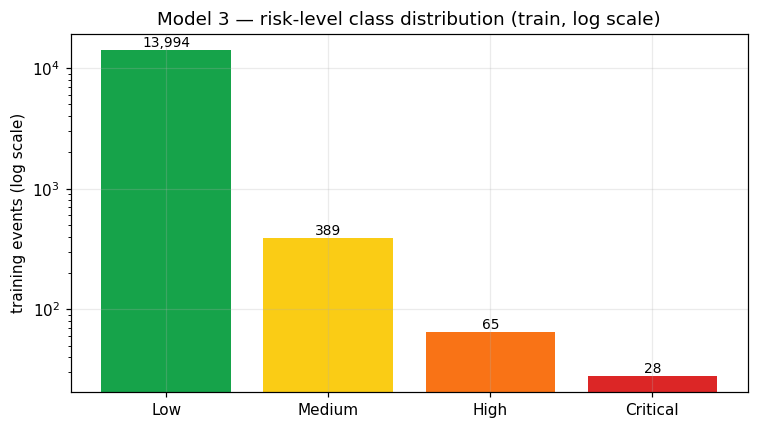

In [22]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(RISK_ORDER, rl["train"].values, color=[SEV_COLORS[c] for c in RISK_ORDER])
ax.set_yscale("log"); ax.set_ylabel("training events (log scale)")
ax.set_title("Model 3 — risk-level class distribution (train, log scale)")
ax.grid(axis="y", alpha=0.25)
for i, v in enumerate(rl["train"].values):
    ax.text(i, v, f"{int(v):,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

### 3.2 Imbalance handling — balanced class weights

Consistent with the project's class-weight philosophy (and given that SMOTE was shown to hurt
in Model 1), we use scikit-learn **balanced** sample weights: each class is weighted inversely
to its frequency, so the rare High/Critical events are not ignored. This deliberately trades
precision for recall — the right bias for a disaster early-warning system.

In [23]:
le_risk = LabelEncoder().fit(RISK_ORDER)          # encode (alphabetical internally)
y_risk_train = le_risk.transform(df_train["risk_level"])
y_risk_test  = le_risk.transform(df_test["risk_level"])
RISK_NATIVE = list(le_risk.classes_)                  # proba-column order: alphabetical
DISPLAY_CODES = list(le_risk.transform(RISK_ORDER))   # codes in Low->Critical order

sw_risk = compute_sample_weight("balanced", y_risk_train)
bw = {c: round(float(sw_risk[df_train["risk_level"].values == c][0]), 2) for c in RISK_ORDER}
w_tbl = pd.DataFrame({
    "raw_count":       df_train["risk_level"].value_counts().reindex(RISK_ORDER),
    "balanced_weight": pd.Series(bw),
})
print("Imbalance strategy = balanced class weights:")
print(w_tbl.to_string())
print(f"\nEffective (weighted) mass is now equal across classes — the rarest class is amplified"
      f"\nup to ~{w_tbl['balanced_weight'].max():.0f}x relative to 'Low'.")

Imbalance strategy = balanced class weights:
          raw_count  balanced_weight
Low           13994             0.26
Medium          389             9.30
High             65            55.68
Critical         28           129.25

Effective (weighted) mass is now equal across classes — the rarest class is amplified
up to ~129x relative to 'Low'.


### 3.3 Model & hyperparameters

The **same production ensemble** as Model 1: **XGBoost (0.60) + CatBoost (0.40)**. We use the
project's fixed-HP reproduction settings (from `streamlit_eda/experiments/preprocessing_experiment.py`,
which mirrors the v4.2 pipeline) so the section runs deterministically without a multi-hour
Optuna search. LightGBM is omitted to match the dropped-in-v4.2 production ensemble.

In [24]:
XGB_PARAMS_M3 = dict(
    n_estimators=500, max_depth=7, learning_rate=0.05, subsample=0.85,
    colsample_bytree=0.8, min_child_weight=3, reg_lambda=2.0, gamma=0.0,
    eval_metric="mlogloss", tree_method="hist", random_state=SEED, n_jobs=-1, verbosity=0,
)
CAT_PARAMS_M3 = dict(
    iterations=500, depth=6, learning_rate=0.05, l2_leaf_reg=3.0,
    loss_function="MultiClass", random_seed=SEED, thread_count=-1,
    verbose=0, allow_writing_files=False,
)
W_XGB_M3, W_CAT_M3 = 0.6, 0.4
print("Model 3 ensemble = XGBoost x 0.6 + CatBoost x 0.4")
print("XGBoost params :", XGB_PARAMS_M3)
print("CatBoost params:", CAT_PARAMS_M3)

Model 3 ensemble = XGBoost x 0.6 + CatBoost x 0.4
XGBoost params : {'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.05, 'subsample': 0.85, 'colsample_bytree': 0.8, 'min_child_weight': 3, 'reg_lambda': 2.0, 'gamma': 0.0, 'eval_metric': 'mlogloss', 'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}
CatBoost params: {'iterations': 500, 'depth': 6, 'learning_rate': 0.05, 'l2_leaf_reg': 3.0, 'loss_function': 'MultiClass', 'random_seed': 42, 'thread_count': -1, 'verbose': 0, 'allow_writing_files': False}


### 3.4 Cross-validation (3-fold, stratified) then fit on full train

We run a 3-fold stratified CV on the training set (the project's StratifiedKFold protocol)
to confirm fold stability, then fit the final ensemble on all training data.

In [25]:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
cv_macros = []
for fold, (ti, vi) in enumerate(skf.split(X_train, y_risk_train), 1):
    sw = compute_sample_weight("balanced", y_risk_train[ti])
    xc = XGBClassifier(**XGB_PARAMS_M3); xc.fit(X_train[ti], y_risk_train[ti], sample_weight=sw)
    cc = CatBoostClassifier(**CAT_PARAMS_M3); cc.fit(X_train[ti], y_risk_train[ti], sample_weight=sw)
    pr = W_XGB_M3 * xc.predict_proba(X_train[vi]) + W_CAT_M3 * cc.predict_proba(X_train[vi])
    mf = f1_score(y_risk_train[vi], np.argmax(pr, axis=1), average="macro", zero_division=0)
    cv_macros.append(mf)
    print(f"  fold {fold}: macro-F1 = {mf:.4f}")
print(f"\n3-fold CV macro-F1: {np.mean(cv_macros):.4f} +/- {np.std(cv_macros):.4f}")

# Final fit on full training data
risk_xgb = XGBClassifier(**XGB_PARAMS_M3); risk_xgb.fit(X_train, y_risk_train, sample_weight=sw_risk)
risk_cat = CatBoostClassifier(**CAT_PARAMS_M3); risk_cat.fit(X_train, y_risk_train, sample_weight=sw_risk)
print("Final risk-level ensemble trained on full train set.")

  fold 1: macro-F1 = 0.3006


  fold 2: macro-F1 = 0.2850


  fold 3: macro-F1 = 0.3115

3-fold CV macro-F1: 0.2990 +/- 0.0109


Final risk-level ensemble trained on full train set.


### 3.5 All classification scores on the holdout set

In [26]:
proba3 = W_XGB_M3 * risk_xgb.predict_proba(X_test) + W_CAT_M3 * risk_cat.predict_proba(X_test)
pred3  = np.argmax(proba3, axis=1)

Yb3 = label_binarize(y_risk_test, classes=range(len(RISK_NATIVE)))
pr_auc_macro_3 = float(np.mean([average_precision_score(Yb3[:, i], proba3[:, i])
                                for i in range(len(RISK_NATIVE))]))
results_m3 = {
    "accuracy":          accuracy_score(y_risk_test, pred3),
    "balanced_accuracy": balanced_accuracy_score(y_risk_test, pred3),
    "precision_macro":   precision_score(y_risk_test, pred3, average="macro", zero_division=0),
    "recall_macro":      recall_score(y_risk_test, pred3, average="macro", zero_division=0),
    "f1_macro":          f1_score(y_risk_test, pred3, average="macro", zero_division=0),
    "precision_weighted":precision_score(y_risk_test, pred3, average="weighted", zero_division=0),
    "recall_weighted":   recall_score(y_risk_test, pred3, average="weighted", zero_division=0),
    "f1_weighted":       f1_score(y_risk_test, pred3, average="weighted", zero_division=0),
    "roc_auc_macro":     roc_auc_score(y_risk_test, proba3, multi_class="ovr", average="macro"),
    "pr_auc_macro":      pr_auc_macro_3,
    "cv_macro_mean":     float(np.mean(cv_macros)),
}
print(f"Holdout set: {len(y_risk_test):,} events\n")
print(f"Accuracy             : {results_m3['accuracy']:.4f}")
print(f"Balanced accuracy    : {results_m3['balanced_accuracy']:.4f}   <-- recall-based, fair under imbalance")
print(f"Precision  (macro)   : {results_m3['precision_macro']:.4f}")
print(f"Recall     (macro)   : {results_m3['recall_macro']:.4f}")
print(f"F1         (macro)   : {results_m3['f1_macro']:.4f}   <-- primary metric")
print(f"Precision  (weighted): {results_m3['precision_weighted']:.4f}")
print(f"Recall     (weighted): {results_m3['recall_weighted']:.4f}")
print(f"F1         (weighted): {results_m3['f1_weighted']:.4f}")
print(f"ROC-AUC OvR (macro)  : {results_m3['roc_auc_macro']:.4f}")
print(f"PR-AUC  OvR (macro)  : {results_m3['pr_auc_macro']:.4f}")
print("\nPer-class classification report (Low -> Critical):")
print(classification_report(y_risk_test, pred3, labels=DISPLAY_CODES,
                            target_names=RISK_ORDER, digits=4, zero_division=0))

Holdout set: 13,070 events

Accuracy             : 0.9269
Balanced accuracy    : 0.9184   <-- recall-based, fair under imbalance
Precision  (macro)   : 0.4363
Recall     (macro)   : 0.9184
F1         (macro)   : 0.5336   <-- primary metric
Precision  (weighted): 0.9762
Recall     (weighted): 0.9269
F1         (weighted): 0.9456
ROC-AUC OvR (macro)  : 0.9860
PR-AUC  OvR (macro)  : 0.7943

Per-class classification report (Low -> Critical):
              precision    recall  f1-score   support

         Low     0.9974    0.9283    0.9616     12691
      Medium     0.2767    0.8669    0.4195       293
        High     0.2348    0.9153    0.3737        59
    Critical     0.2364    0.9630    0.3796        27

    accuracy                         0.9269     13070
   macro avg     0.4363    0.9184    0.5336     13070
weighted avg     0.9762    0.9269    0.9456     13070



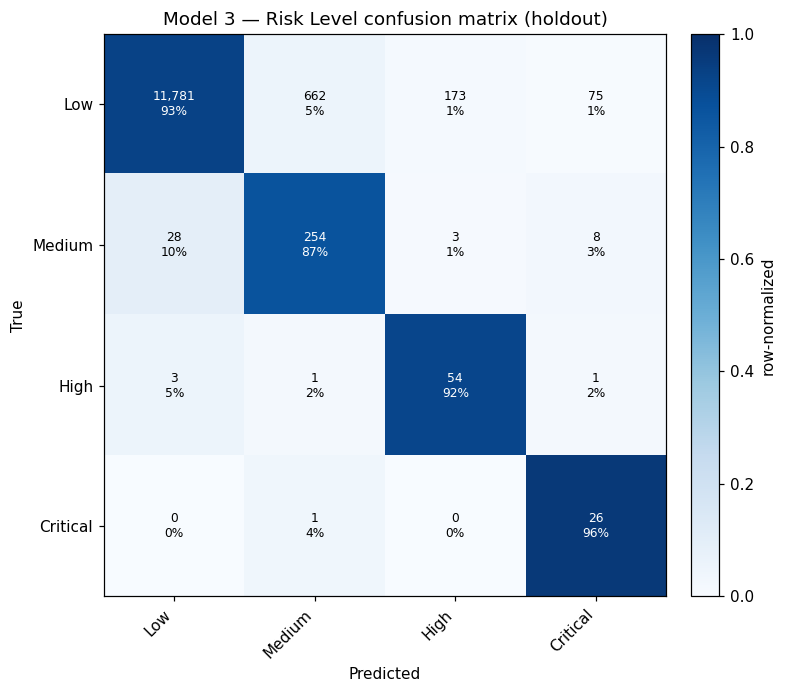

In [27]:
plot_confusion(y_risk_test, pred3, RISK_ORDER,
               "Model 3 — Risk Level confusion matrix (holdout)", labels=DISPLAY_CODES)

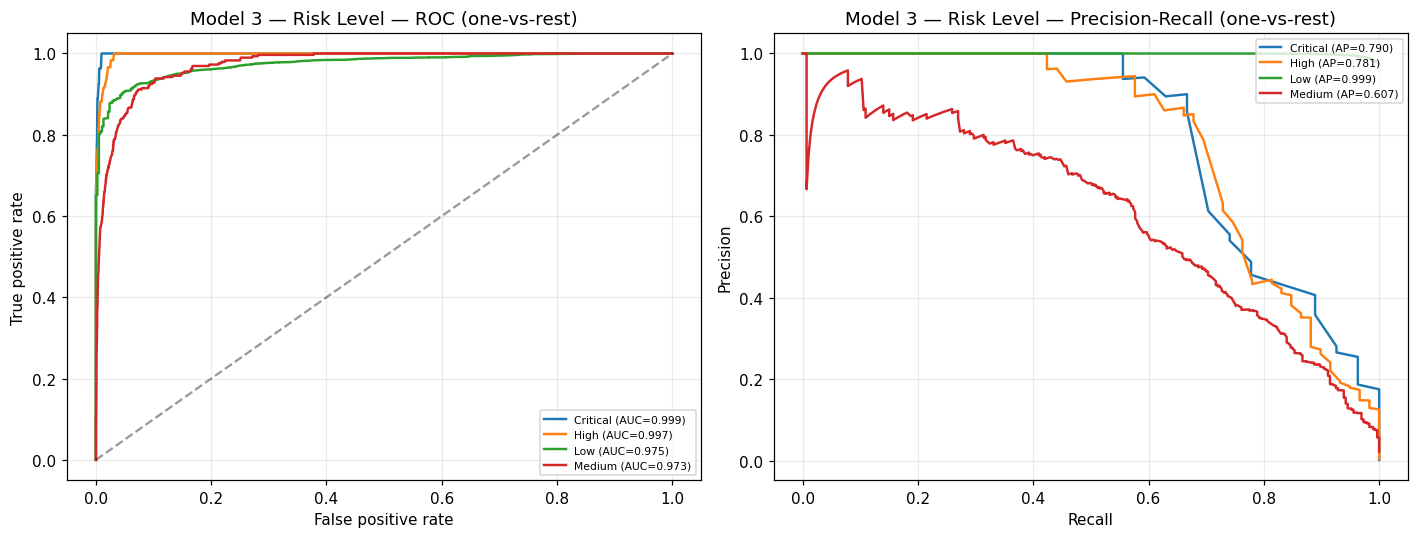

In [28]:
plot_roc_pr(y_risk_test, proba3, RISK_NATIVE, "Model 3 — Risk Level")

### 3.6 Explainability — feature importances & SHAP

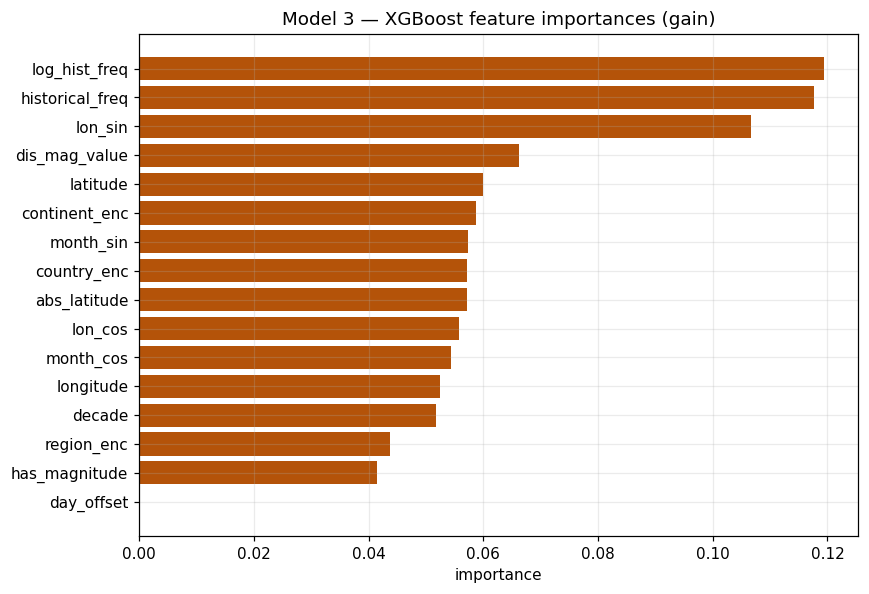

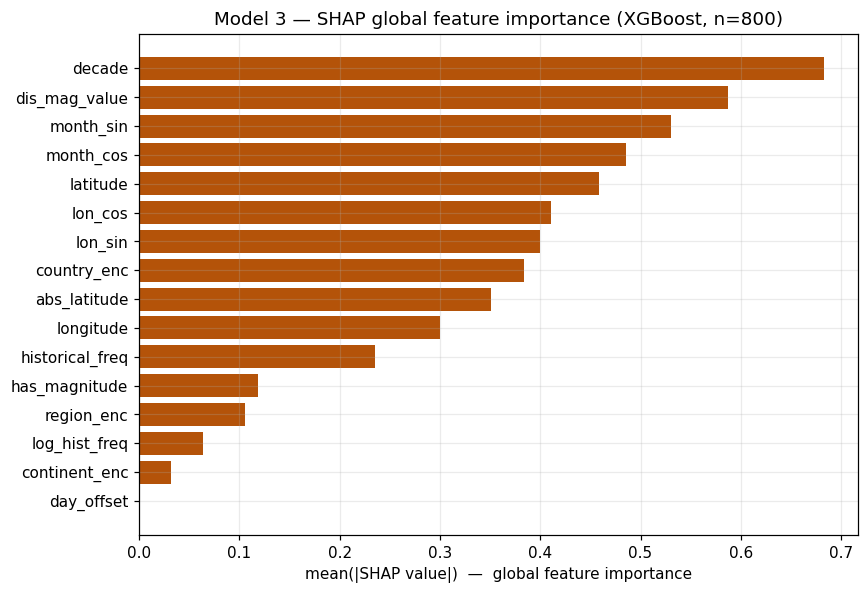

In [29]:
plot_importances(risk_xgb.feature_importances_, FEATURE_NAMES,
                 "Model 3 — XGBoost feature importances (gain)", color="#b45309")
idx = rng.choice(len(X_test), size=min(800, len(X_test)), replace=False)
_ = shap_global_bar(risk_xgb, X_test[idx], FEATURE_NAMES,
                    "Model 3 — SHAP global feature importance (XGBoost, n=800)", color="#b45309")

### 3.7 Macro-vs-weighted again — and what the numbers mean

Model 3 is the most dramatic illustration of the trade-off:

- **Weighted-F1 ≈ 0.95** and **accuracy ≈ 0.93** look excellent — but they are inflated by the
  ~97 % "Low" class.
- **Macro-F1 ≈ 0.53** tells the real story: with balanced weights the model achieves **high
  recall on every class** (it rarely *misses* a High/Critical event — exactly what a warning
  system needs, reflected in the **~0.92 balanced accuracy**), but at low **precision** on the
  rare classes (many false alarms from the huge Low population).

**The deeper lesson:** you *cannot* reliably classify catastrophic risk level from location &
season alone — risk depends on the actual impact magnitude. That is precisely why the
production system **computes** risk level from predicted impact + probability rather than
predicting it directly. This section both documents the risk-scoring logic and empirically
justifies that architectural choice.

# Model Comparison & Conclusions

A side-by-side summary of all three models, followed by a written interpretation.

In [30]:
# Headline summary table (one row per model)
summary = pd.DataFrame([
    {"Model": "1 · Disaster Type Predictor", "Task": "Classification (8-class)",
     "Source": "loaded artifact (v4.2)", "Headline metric": "Macro-F1",
     "Headline": round(results_m1["f1_macro"], 4),
     "Accuracy": round(results_m1["accuracy"], 4),
     "Balanced acc": round(results_m1["balanced_accuracy"], 4),
     "Weighted-F1": round(results_m1["f1_weighted"], 4),
     "ROC-AUC (macro)": round(results_m1["roc_auc_macro"], 4)},
    {"Model": "2 · Impact Prediction", "Task": "Regression (4 targets)",
     "Source": "loaded artifact", "Headline metric": "Mean R2 (log)",
     "Headline": round(results_m2["mean_R2_log"], 4),
     "Accuracy": np.nan, "Balanced acc": np.nan, "Weighted-F1": np.nan, "ROC-AUC (macro)": np.nan},
    {"Model": "3 · Risk Level Classifier", "Task": "Classification (4-class)",
     "Source": "retrained (no artifact)", "Headline metric": "Macro-F1",
     "Headline": round(results_m3["f1_macro"], 4),
     "Accuracy": round(results_m3["accuracy"], 4),
     "Balanced acc": round(results_m3["balanced_accuracy"], 4),
     "Weighted-F1": round(results_m3["f1_weighted"], 4),
     "ROC-AUC (macro)": round(results_m3["roc_auc_macro"], 4)},
])
print("=" * 100)
print("SAFEEARTH — HEADLINE SCORES FOR ALL THREE MODELS")
print("=" * 100)
print(summary.to_string(index=False))

print("\nModel 2 — per-target regression detail (log-space is the fair headline):")
print(results_m2["per_target"][["R2_log", "MAE_log", "RMSE_log", "R2_orig", "MAPE_orig(nz)"]].to_string())

SAFEEARTH — HEADLINE SCORES FOR ALL THREE MODELS
                      Model                     Task                  Source Headline metric  Headline  Accuracy  Balanced acc  Weighted-F1  ROC-AUC (macro)
1 · Disaster Type Predictor Classification (8-class)  loaded artifact (v4.2)        Macro-F1    0.7052    0.7537        0.7251       0.7587           0.9624
      2 · Impact Prediction   Regression (4 targets)         loaded artifact   Mean R2 (log)    0.3772       NaN           NaN          NaN              NaN
  3 · Risk Level Classifier Classification (4-class) retrained (no artifact)        Macro-F1    0.5336    0.9269        0.9184       0.9456           0.9860

Model 2 — per-target regression detail (log-space is the fair headline):
          R2_log  MAE_log  RMSE_log  R2_orig  MAPE_orig(nz)
target                                                     
deaths    0.4127   1.1294    1.4442   0.0041          1.036
injuries  0.3876   1.1079    1.6062  -0.0003          1.169
affected 

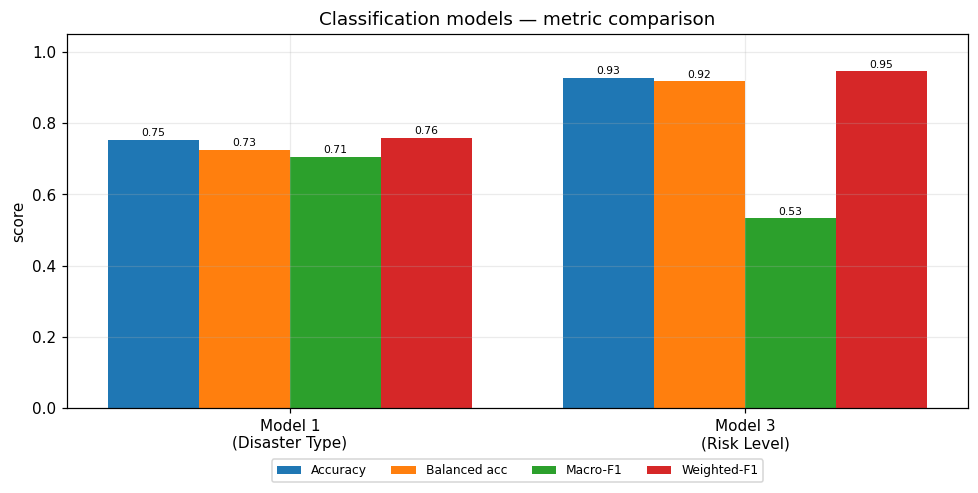

In [31]:
# Visual comparison of the two classifiers (macro vs weighted F1, accuracy, balanced acc)
labels = ["Model 1\n(Disaster Type)", "Model 3\n(Risk Level)"]
metrics = {
    "Accuracy":      [results_m1["accuracy"],          results_m3["accuracy"]],
    "Balanced acc":  [results_m1["balanced_accuracy"], results_m3["balanced_accuracy"]],
    "Macro-F1":      [results_m1["f1_macro"],          results_m3["f1_macro"]],
    "Weighted-F1":   [results_m1["f1_weighted"],       results_m3["f1_weighted"]],
}
x = np.arange(len(labels)); width = 0.2
fig, ax = plt.subplots(figsize=(9, 4.6))
for k, (name, vals) in enumerate(metrics.items()):
    ax.bar(x + (k - 1.5) * width, vals, width, label=name)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylim(0, 1.05)
ax.set_ylabel("score"); ax.set_title("Classification models — metric comparison")
ax.legend(ncol=4, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.12))
ax.grid(axis="y", alpha=0.25)
for k, (name, vals) in enumerate(metrics.items()):
    for xi, v in zip(x + (k - 1.5) * width, vals):
        ax.text(xi, v + 0.01, f"{v:.2f}", ha="center", fontsize=7)
plt.tight_layout(); plt.show()

## What the numbers mean — and where each model is weak

**Model 1 — Disaster Type Predictor (Macro-F1 ≈ 0.71, Weighted-F1 ≈ 0.76, ROC-AUC ≈ 0.96).**
A strong, honest result across 8 classes from a century-old, heavily-incomplete database.
**Earthquake (~0.98 F1)** is near-perfect thanks to ~94 % magnitude coverage and a distinct
Richter scale. **Flood / Storm / Extreme temperature** all sit ≥0.74. The weakness is the
rare, signal-poor classes: **Landslide (~0.48)** and **Drought (~0.59)** — they have almost no
magnitude readings and overlap spatially with floods/storms. More magnitude coverage for these
types (not a fancier algorithm, and not resampling — SMOTE was shown to *hurt*) is the
highest-leverage fix.

**Model 2 — Impact Prediction (mean log-space R² modest; weakest on injuries).** The four
regressors capture the *location* signal but are disaster-type-blind by construction, so
log-space R² is moderate and lowest for **injuries** (~26 % data coverage) and **damage**
(~34 %). Original-scale R² is brittle because the targets are skewed 100×+ (a handful of
catastrophes dominate the error). This is *exactly why production never serves the raw
regressor output*: it blends these predictions with disaster-type-specific **EM-DAT medians**
and enforces `deaths ≤ injured ≤ affected`. The model is the location half of a
location × type product.

**Model 3 — Risk Level Classifier (Accuracy ≈ 0.93, Balanced acc ≈ 0.92, Macro-F1 ≈ 0.53,
Weighted-F1 ≈ 0.95).** With ~97 % of events at "Low", balanced weights give the model **high
recall on the rare High/Critical bands** (it seldom misses a dangerous event — the correct
bias for early warning) at the cost of **precision** (false alarms). The huge gap between
weighted-F1 (~0.95) and macro-F1 (~0.53) is the textbook signature of extreme imbalance. The
key finding: **risk level is not reliably predictable from location & season alone** — which
is exactly why the live site *computes* it from predicted impact + probability rather than
classifying it.

### The macro-vs-weighted F1 thread that ties it together
Both classifiers are reported with **macro-F1 as the primary metric**. Under heavy imbalance,
accuracy and weighted-F1 flatter a model by rewarding the common classes; macro-F1 (equal
weight per class) exposes the weak ones. SafeEarth optimises macro-F1 throughout — that single
choice drives the rejection of SMOTE/balanced-weights in Model 1 and frames the honest
reading of Model 3.

### Faithfulness & reproducibility recap
- Models 1 & 2 were evaluated **directly from the production `.pkl` artifacts**; the notebook's
  independently-fit encoders were asserted identical to the saved ones, and Model 1 reproduced
  the published holdout numbers (Macro-F1 0.7052 / Weighted-F1 0.7587) exactly.
- Model 3 was retrained on the **same features, preprocessing, two-file split, class-weight
  imbalance handling and XGBoost+CatBoost ensemble**, with all P99 caps / encoders fit on
  train only (leakage-safe) and seeds fixed at 42.
